In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from src.models.sarima_model import train_sarima
from src.models.baseline_model import train_baseline
from src.models.prophet_model import train_prophet

import mlflow
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('finops-forecasting')

df = pd.read_csv('../data/raw/cloud_costs.csv', parse_dates=['date'])
services = ['EC2', 'S3', 'RDS', 'Lambda', 'CloudFront', 'EKS', 'Redshift']
print(f"Données chargées : {len(df)} lignes")

Données chargées : 7672 lignes


In [16]:
sarima_results   = {}
baseline_results = {}
prophet_results  = {}

for service in services:
    print(f"\n--- {service} ---")
    prophet_results[service]  = train_prophet(df, service)
    sarima_results[service]   = train_sarima(df, service)
    baseline_results[service] = train_baseline(df, service)


--- EC2 ---


22:39:07 - cmdstanpy - INFO - Chain [1] start processing
22:39:07 - cmdstanpy - INFO - Chain [1] done processing


EC2 — PROPHET MAPE: 8.6%, RMSE: 57$
EC2 — SARIMA MAPE: 7.3%, RMSE: 49$
EC2 — Baseline MAPE: 12.4%, RMSE: 78$

--- S3 ---


22:39:10 - cmdstanpy - INFO - Chain [1] start processing
22:39:10 - cmdstanpy - INFO - Chain [1] done processing


S3 — PROPHET MAPE: 8.7%, RMSE: 22$
S3 — SARIMA MAPE: 7.6%, RMSE: 21$
S3 — Baseline MAPE: 14.2%, RMSE: 27$

--- RDS ---


...

CloudFront — PROPHET MAPE: 8.0%, RMSE: 16$
CloudFront — SARIMA MAPE: 11.5%, RMSE: 18$
CloudFront — Baseline MAPE: 13.8%, RMSE: 20$

--- EKS ---


22:39:18 - cmdstanpy - INFO - Chain [1] start processing
22:39:18 - cmdstanpy - INFO - Chain [1] done processing


EKS — PROPHET MAPE: 8.4%, RMSE: 89$
EKS — SARIMA MAPE: 9.1%, RMSE: 95$
EKS — Baseline MAPE: 11.7%, RMSE: 99$

--- Redshift ---


22:39:19 - cmdstanpy - INFO - Chain [1] start processing
22:39:19 - cmdstanpy - INFO - Chain [1] done processing


Redshift — PROPHET MAPE: 7.9%, RMSE: 55$
Redshift — SARIMA MAPE: 12.6%, RMSE: 61$
Redshift — Baseline MAPE: 14.8%, RMSE: 63$


In [17]:
rows = []
for service in services:
    rows.append({
        'Service':        service,
        'Baseline MAPE':  f"{baseline_results[service]['mape']:.1f}%",
        'Baseline RMSE':  f"{baseline_results[service]['rmse']:.0f}$",
        'SARIMA MAPE':    f"{sarima_results[service]['mape']:.1f}%",
        'SARIMA RMSE':    f"{sarima_results[service]['rmse']:.0f}$",
        'Prophet MAPE':   f"{prophet_results[service]['mape']:.1f}%",
        'Prophet RMSE':   f"{prophet_results[service]['rmse']:.0f}$",
    })

benchmark = pd.DataFrame(rows)

# Ligne moyenne
benchmark.loc['Moyenne'] = [
    'MOYENNE',
    f"{pd.Series([baseline_results[s]['mape'] for s in services]).mean():.1f}%",
    f"{pd.Series([baseline_results[s]['rmse'] for s in services]).mean():.0f}$",
    f"{pd.Series([sarima_results[s]['mape'] for s in services]).mean():.1f}%",
    f"{pd.Series([sarima_results[s]['rmse'] for s in services]).mean():.0f}$",
    f"{pd.Series([prophet_results[s]['mape'] for s in services]).mean():.1f}%",
    f"{pd.Series([prophet_results[s]['rmse'] for s in services]).mean():.0f}$",
]

from IPython.display import display
display(benchmark)

,Service,Baseline MAPE,Baseline RMSE,SARIMA MAPE,SARIMA RMSE,Prophet MAPE,Prophet RMSE
0,EC2,12.4%,78$,7.3%,49$,8.6%,57$
1,S3,14.2%,27$,7.6%,21$,8.7%,22$
2,RDS,10.4%,33$,8.2%,23$,8.2%,24$
3,Lambda,13.2%,10$,8.1%,8$,8.1%,8$
4,CloudFront,13.8%,20$,11.5%,18$,8.0%,16$
5,EKS,11.7%,99$,9.1%,95$,8.4%,89$
6,Redshift,14.8%,63$,12.6%,61$,7.9%,55$
Moyenne,MOYENNE,12.9%,47$,9.2%,39$,8.3%,39$


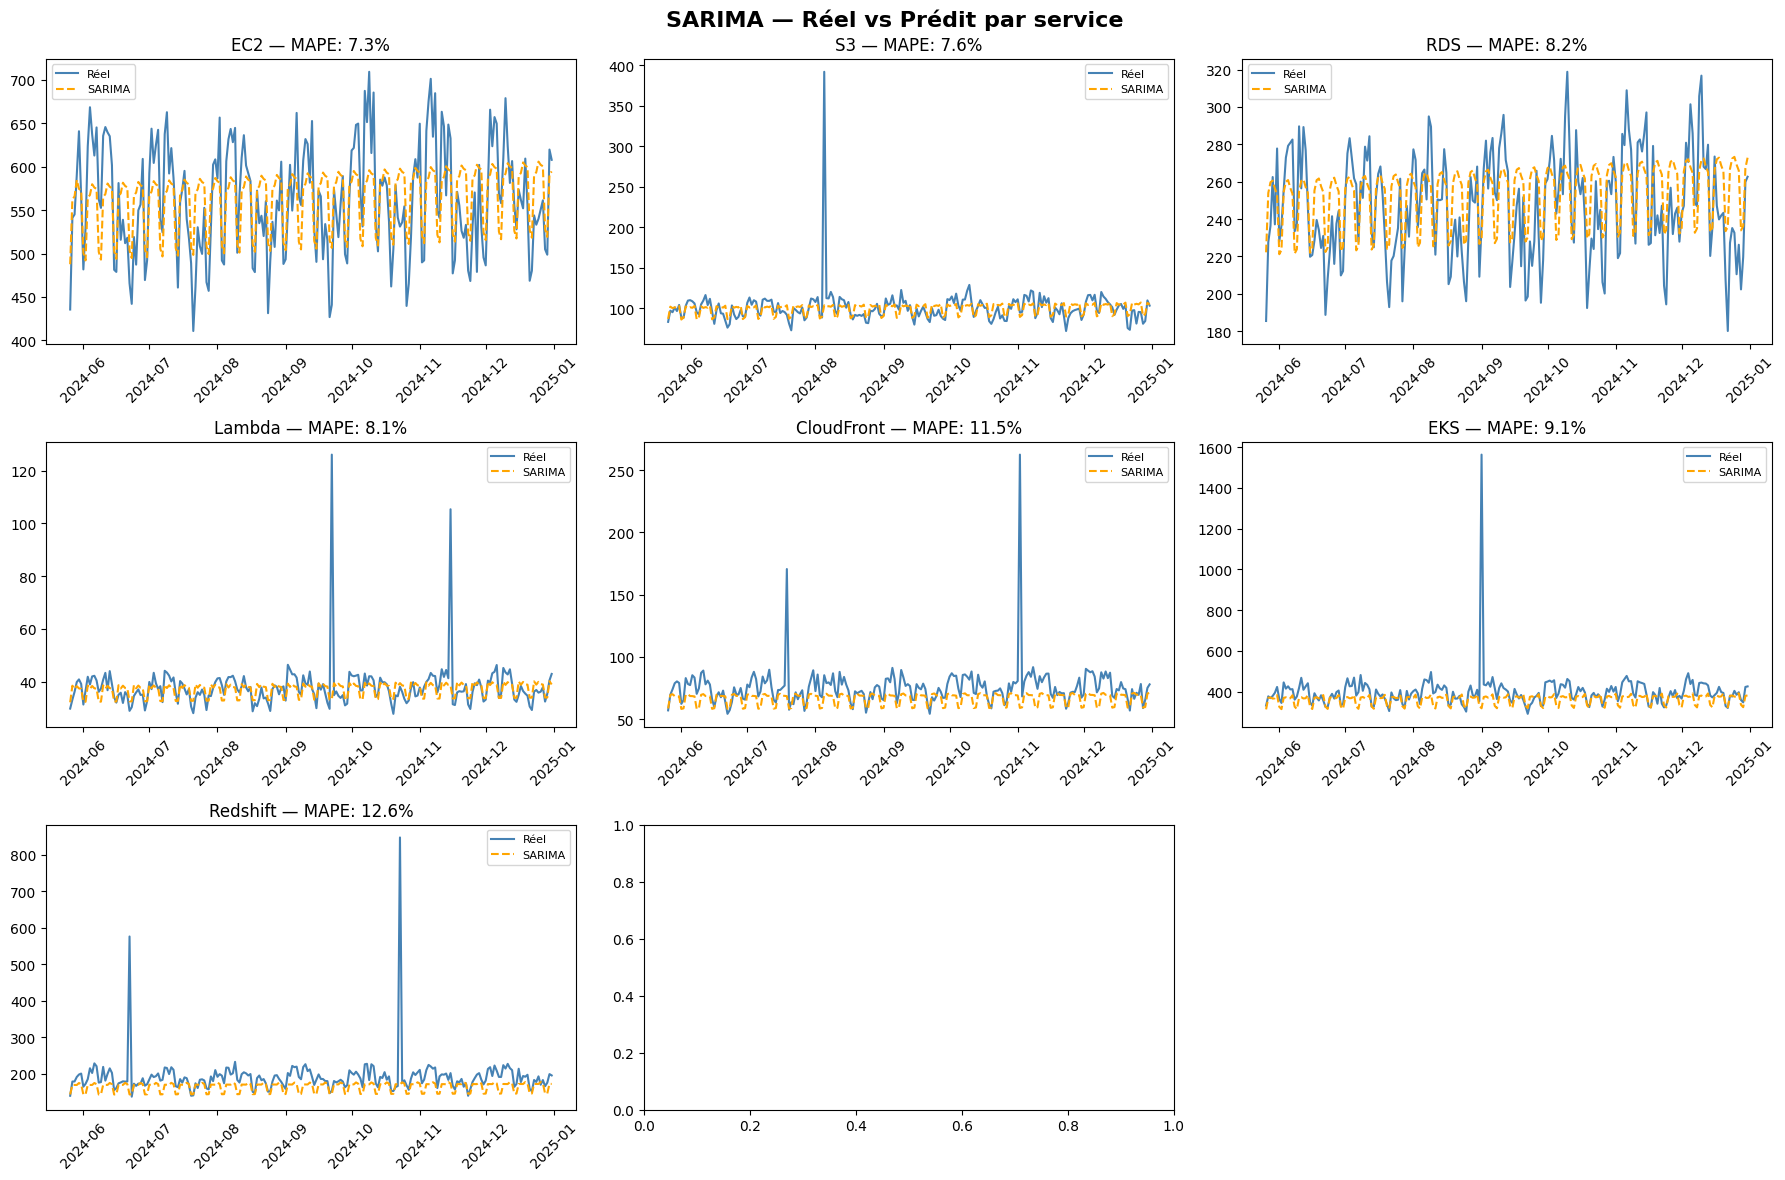

Graphique sauvegardé !


In [18]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, service in enumerate(services):
    ax = axes[i]
    test  = sarima_results[service]['test']
    pred  = sarima_results[service]['predictions']

    ax.plot(test.index, test.values, label='Réel', color='steelblue')
    ax.plot(test.index, pred,        label='SARIMA', color='orange', linestyle='--')
    ax.set_title(f'{service} — MAPE: {sarima_results[service]["mape"]:.1f}%')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

# Cacher le dernier subplot vide
axes[-1].set_visible(False)

plt.suptitle('SARIMA — Réel vs Prédit par service', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/outputs/benchmark_sarima.png', dpi=150)
plt.show()
print("Graphique sauvegardé !")

In [19]:
prophet_results

{'EC2': {'model': <prophet.forecaster.Prophet at 0x1a814fa0bb0>,
  'mape': 8.593979960050588,
  'rmse': 56.61427254927171,
  'predictions': array([498.93771423, 568.31706493, 569.2149876 , 578.65359946,
         572.21002089, 567.83518242, 492.55274066, 481.29738916,
         550.84460688, 552.38501042, 562.93305203, 558.04579858,
         555.64216535, 482.70259621, 474.10845645, 546.57315229,
         551.2181059 , 564.9832829 , 563.34795692, 564.15202901,
         494.29783477, 488.59164508, 563.67681452, 570.61164821,
         586.28163012, 586.12164825, 587.93849267, 518.61352529,
         512.94470209, 587.579887  , 593.59452314, 607.90331027,
         605.98153967, 605.68638828, 533.95810597, 525.66031994,
         597.5114452 , 600.66032274, 612.0957931 , 607.36591854,
         604.39721703, 530.1939023 , 519.67641098, 589.61125766,
         591.18538502, 601.41475447, 595.8629188 , 592.45995916,
         518.20178869, 507.98910146, 578.55799457, 581.05540708,
         592.4490

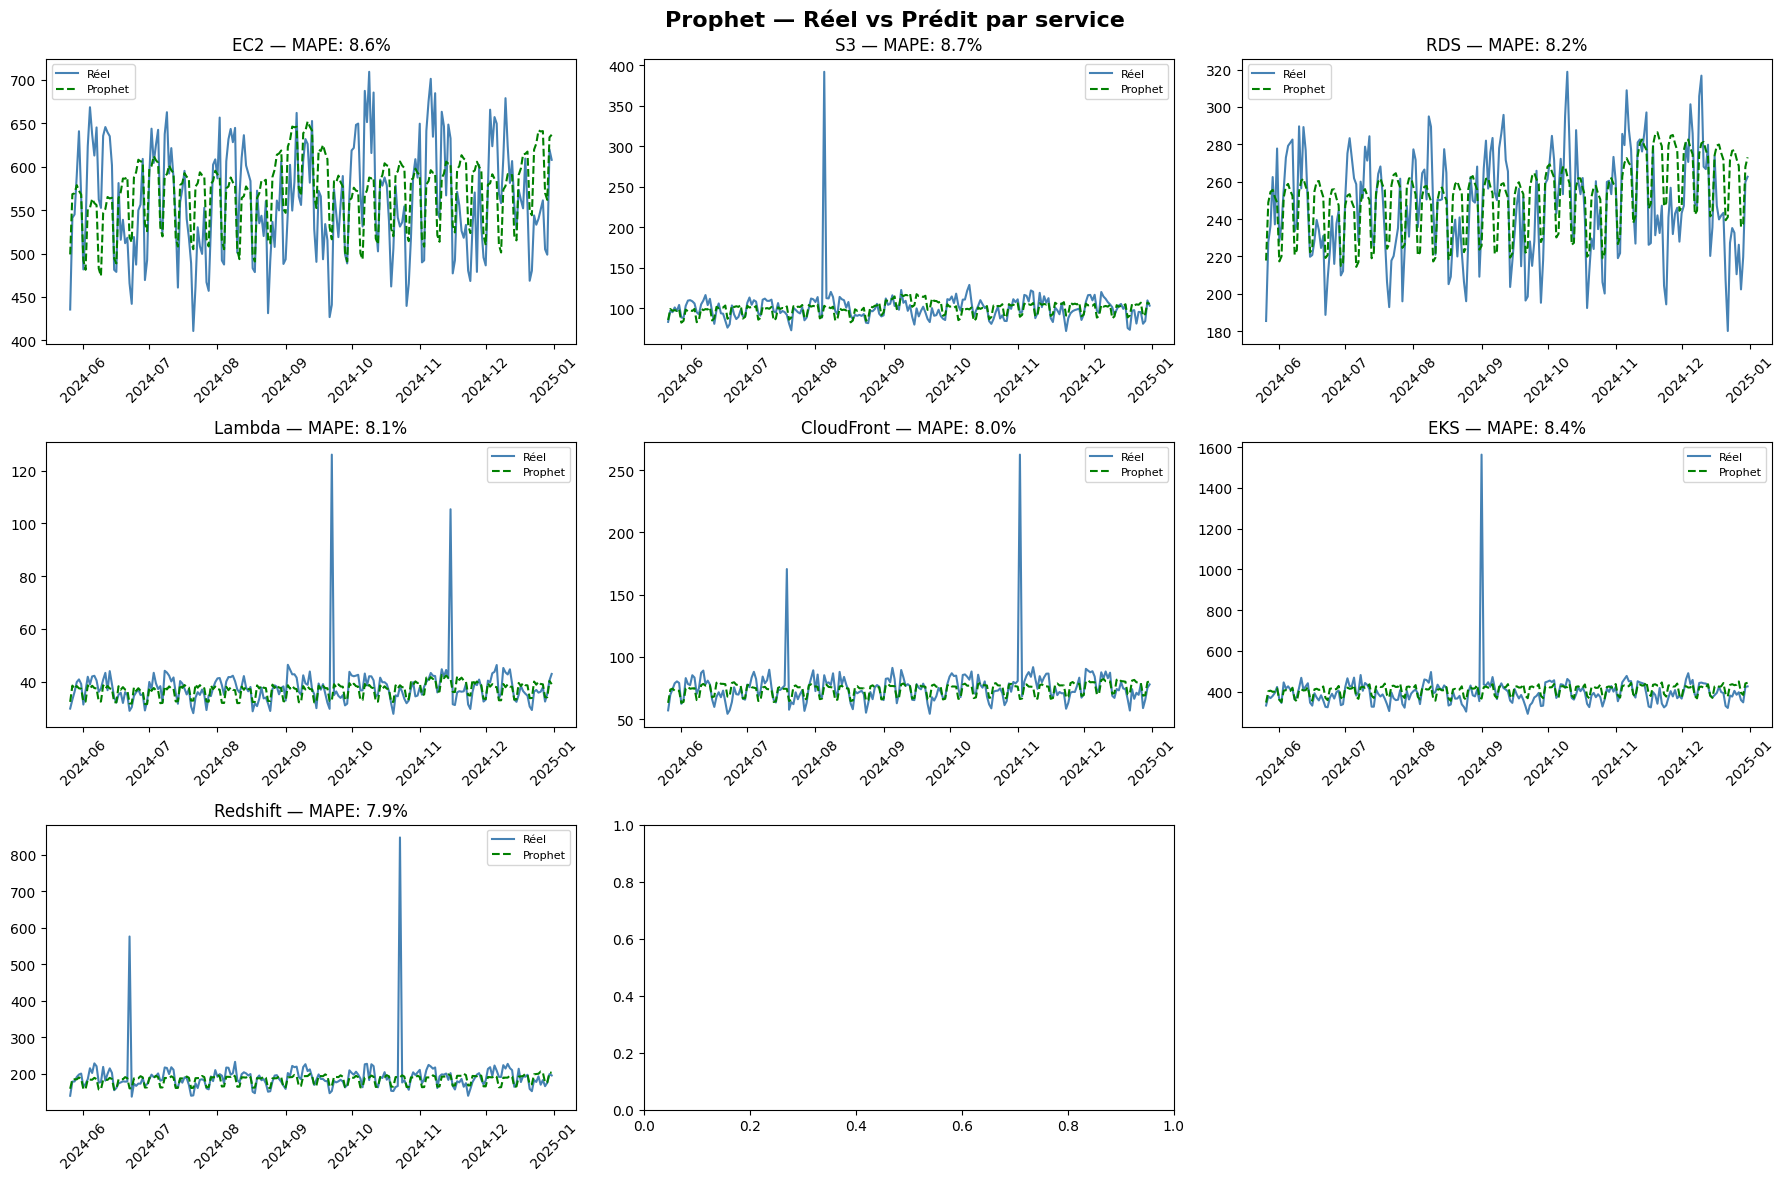

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, service in enumerate(services):
    ax = axes[i]
    test  = prophet_results[service]['test']
    pred  = prophet_results[service]['predictions']

    # Prophet retourne un DataFrame avec colonne 'ds' et 'y'
    ax.plot(test['ds'].values, test['y'].values, label='Réel',    color='steelblue')
    ax.plot(test['ds'].values, pred,              label='Prophet', color='green', linestyle='--')
    ax.set_title(f'{service} — MAPE: {prophet_results[service]["mape"]:.1f}%')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)

plt.suptitle('Prophet — Réel vs Prédit par service', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/outputs/benchmark_prophet.png', dpi=150)
plt.show()

In [21]:
# SARIMA
best_sarima  = min(sarima_results,  key=lambda s: sarima_results[s]['mape'])
worst_sarima = max(sarima_results,  key=lambda s: sarima_results[s]['mape'])
mape_sarima  = pd.Series([sarima_results[s]['mape']  for s in services]).mean()

# Prophet
best_prophet  = min(prophet_results, key=lambda s: prophet_results[s]['mape'])
worst_prophet = max(prophet_results, key=lambda s: prophet_results[s]['mape'])
mape_prophet  = pd.Series([prophet_results[s]['mape'] for s in services]).mean()

print("=" * 45)
print(f"MAPE moyen SARIMA    : {mape_sarima:.1f}%")
print(f"Meilleur service     : {best_sarima}  ({sarima_results[best_sarima]['mape']:.1f}%)")
print(f"Service difficile    : {worst_sarima} ({sarima_results[worst_sarima]['mape']:.1f}%)")
print("=" * 45)
print(f"MAPE moyen Prophet   : {mape_prophet:.1f}%")
print(f"Meilleur service     : {best_prophet}  ({prophet_results[best_prophet]['mape']:.1f}%)")
print(f"Service difficile    : {worst_prophet} ({prophet_results[worst_prophet]['mape']:.1f}%)")
print("=" * 45)

# Conclusion automatique
if mape_prophet < mape_sarima:
    print(f"\n✅ Modèle retenu : PROPHET  ({mape_prophet:.1f}% vs {mape_sarima:.1f}%)")
else:
    print(f"\n✅ Modèle retenu : SARIMA   ({mape_sarima:.1f}% vs {mape_prophet:.1f}%)")

print(f"→ Sera utilisé à l'étape 5 pour la détection d'anomalies")

MAPE moyen SARIMA    : 9.2%
Meilleur service     : EC2  (7.3%)
Service difficile    : Redshift (12.6%)
MAPE moyen Prophet   : 8.3%
Meilleur service     : Redshift  (7.9%)
Service difficile    : S3 (8.7%)

✅ Modèle retenu : PROPHET  (8.3% vs 9.2%)
→ Sera utilisé à l'étape 5 pour la détection d'anomalies
